In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# Supaya GPU tidak langsung makan semua VRAM
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth aktif.")
    except RuntimeError as e:
        print(e)
else:
    print("GPU tidak terdeteksi.")

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth aktif.


In [2]:
BASE_DIR = r"D:\Skripsi\EfficientNetV2S_Sawit\dataset_split"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

class_names = ["belum_masak", "masak", "terlalu_masak"]
num_classes = len(class_names)

print("Train dir:", TRAIN_DIR)
print("Val dir  :", VAL_DIR)
print("Test dir :", TEST_DIR)
print("Jumlah kelas:", num_classes)

Train dir: D:\Skripsi\EfficientNetV2S_Sawit\dataset_split\train
Val dir  : D:\Skripsi\EfficientNetV2S_Sawit\dataset_split\val
Test dir : D:\Skripsi\EfficientNetV2S_Sawit\dataset_split\test
Jumlah kelas: 3


In [3]:
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split_name, split_dir in [
    ("TRAIN", TRAIN_DIR),
    ("VAL", VAL_DIR),
    ("TEST", TEST_DIR)
]:
    print(f"\n{split_name}")
    total_split = 0
    
    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        
        count = len([
            f for f in os.listdir(class_dir)
            if f.lower().endswith(valid_ext)
        ])
        
        total_split += count
        print(f"{class_name}: {count}")
    
    print(f"Total {split_name}: {total_split}")


TRAIN
belum_masak: 1808
masak: 1692
terlalu_masak: 1747
Total TRAIN: 5247

VAL
belum_masak: 387
masak: 362
terlalu_masak: 374
Total VAL: 1123

TEST
belum_masak: 388
masak: 364
terlalu_masak: 376
Total TEST: 1128


In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_data = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", train_data.class_names)

Found 5247 files belonging to 3 classes.
Found 1123 files belonging to 3 classes.
Found 1128 files belonging to 3 classes.
Class names: ['belum_masak', 'masak', 'terlalu_masak']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

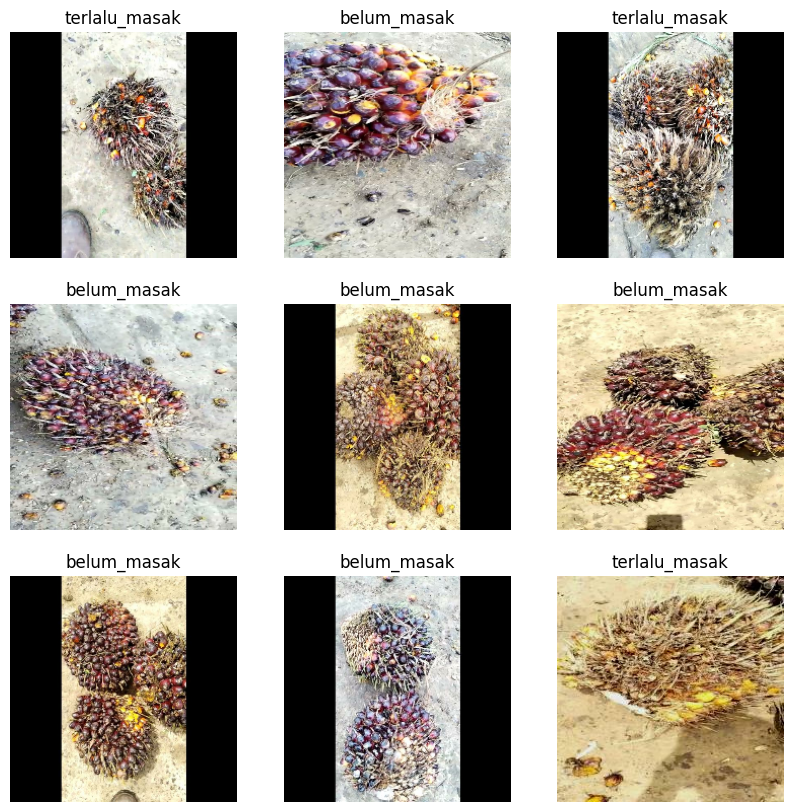

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [8]:
base_model = EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# Untuk EfficientNetV2 dari Keras, preprocess_input aman dipakai
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

82420632/82420632 [==============================] - 9s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetv2-s (Functiona  (None, 7, 7, 1280)       20331360  
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0      

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
MODEL_DIR = r"D:\Skripsi\EfficientNetV2S_Sawit\models"
os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint_path = os.path.join(MODEL_DIR, "best_efficientnetv2s_sawit_stage1.keras")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [11]:
EPOCHS = 15

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
328/328 [==============================] - ETA: 0s - loss: 0.9519 - accuracy: 0.5441
Epoch 1: val_accuracy improved from -inf to 0.64292, saving model to D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_stage1.keras
328/328 [==============================] - 112s 265ms/step - loss: 0.9519 - accuracy: 0.5441 - val_loss: 0.8202 - val_accuracy: 0.6429 - lr: 1.0000e-04
Epoch 2/15
328/328 [==============================] - ETA: 0s - loss: 0.7793 - accuracy: 0.6737
Epoch 2: val_accuracy improved from 0.64292 to 0.72573, saving model to D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_stage1.keras
328/328 [==============================] - 73s 222ms/step - loss: 0.7793 - accuracy: 0.6737 - val_loss: 0.7120 - val_accuracy: 0.7257 - lr: 1.0000e-04
Epoch 3/15
328/328 [==============================] - ETA: 0s - loss: 0.7017 - accuracy: 0.7071
Epoch 3: val_accuracy improved from 0.72573 to 0.76046, saving model to D:\Skripsi\EfficientNetV2S_Sawit\mod

In [12]:
best_model_stage1 = tf.keras.models.load_model(
    r"D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_stage1.keras"
)

print("Model terbaik stage 1 berhasil diload.")

Model terbaik stage 1 berhasil diload.


In [13]:
test_loss, test_acc = best_model_stage1.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

71/71 [==============================] - 12s 109ms/step - loss: 0.4595 - accuracy: 0.8245
Test Loss: 0.4595218300819397
Test Accuracy: 0.8244680762290955


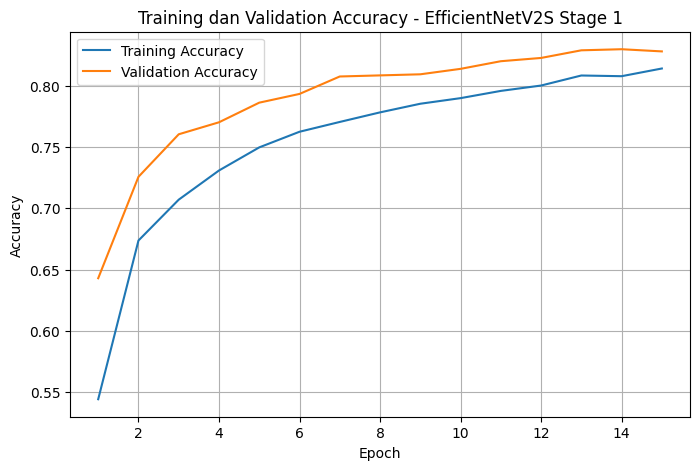

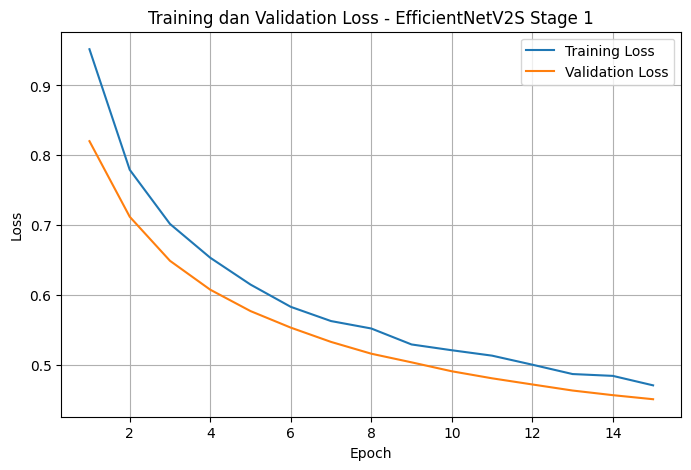

In [14]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training dan Validation Accuracy - EfficientNetV2S Stage 1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training dan Validation Loss - EfficientNetV2S Stage 1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
best_model_stage1 = tf.keras.models.load_model(
    r"D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_stage1.keras"
)

best_model_stage1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetv2-s (Functiona  (None, 7, 7, 1280)       20331360  
 l)                                                              
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                             

In [16]:
for i, layer in enumerate(best_model_stage1.layers):
    print(i, layer.name, layer.trainable)

0 input_2 True
1 data_augmentation True
2 efficientnetv2-s True
3 global_average_pooling2d True
4 dropout True
5 dense True


In [17]:
base_model = best_model_stage1.get_layer("efficientnetv2-s")
print("Base model ditemukan:", base_model.name)
print("Jumlah layer base model:", len(base_model.layers))

Base model ditemukan: efficientnetv2-s
Jumlah layer base model: 513


In [18]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Total layer base model:", len(base_model.layers))
print("Layer dibekukan sampai:", fine_tune_at)
print("Layer yang dibuka:", len(base_model.layers) - fine_tune_at)

Total layer base model: 513
Layer dibekukan sampai: 384
Layer yang dibuka: 129


In [19]:
best_model_stage1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
checkpoint_finetune_path = r"D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_finetuned.keras"

callbacks_finetune = [
    ModelCheckpoint(
        checkpoint_finetune_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [21]:
FINE_TUNE_EPOCHS = 15

history_finetune = best_model_stage1.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks_finetune
)

Epoch 1/15
328/328 [==============================] - ETA: 0s - loss: 0.4065 - accuracy: 0.8306
Epoch 1: val_accuracy improved from -inf to 0.84061, saving model to D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_finetuned.keras
328/328 [==============================] - 113s 272ms/step - loss: 0.4065 - accuracy: 0.8306 - val_loss: 0.3636 - val_accuracy: 0.8406 - lr: 1.0000e-05
Epoch 2/15
328/328 [==============================] - ETA: 0s - loss: 0.3190 - accuracy: 0.8666
Epoch 2: val_accuracy improved from 0.84061 to 0.84773, saving model to D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_finetuned.keras
328/328 [==============================] - 85s 259ms/step - loss: 0.3190 - accuracy: 0.8666 - val_loss: 0.3261 - val_accuracy: 0.8477 - lr: 1.0000e-05
Epoch 3/15
328/328 [==============================] - ETA: 0s - loss: 0.2800 - accuracy: 0.8855
Epoch 3: val_accuracy improved from 0.84773 to 0.84862, saving model to D:\Skripsi\EfficientNetV2S_Saw

In [22]:
best_model_finetuned = tf.keras.models.load_model(
    r"D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_finetuned.keras"
)

print("Model fine-tuned terbaik berhasil diload.")

Model fine-tuned terbaik berhasil diload.


In [23]:
test_loss, test_acc = best_model_finetuned.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

71/71 [==============================] - 10s 94ms/step - loss: 0.2320 - accuracy: 0.9087
Test Loss: 0.23202316462993622
Test Accuracy: 0.908687949180603


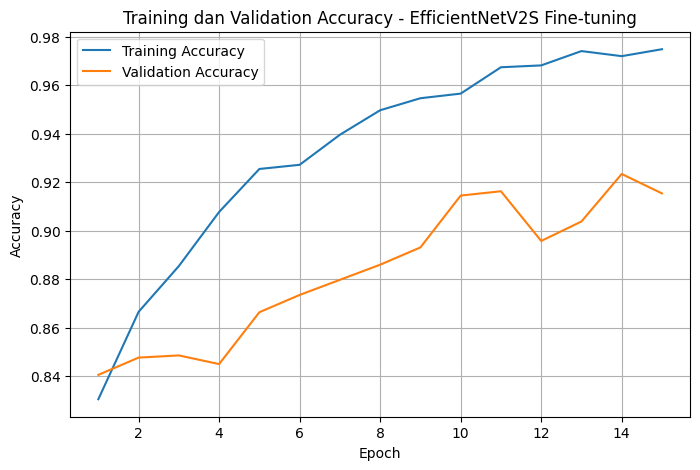

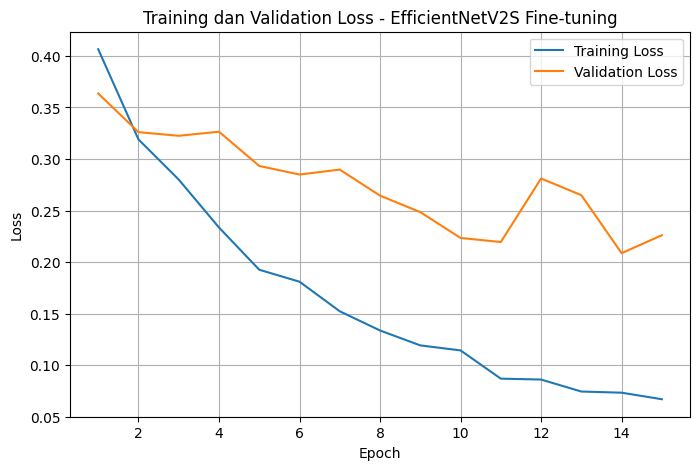

In [24]:
acc = history_finetune.history["accuracy"]
val_acc = history_finetune.history["val_accuracy"]
loss = history_finetune.history["loss"]
val_loss = history_finetune.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training dan Validation Accuracy - EfficientNetV2S Fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training dan Validation Loss - EfficientNetV2S Fine-tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Classification Report:
               precision    recall  f1-score   support

  belum_masak       0.87      0.94      0.90       388
        masak       0.92      0.80      0.86       364
terlalu_masak       0.95      0.98      0.96       376

     accuracy                           0.91      1128
    macro avg       0.91      0.91      0.91      1128
 weighted avg       0.91      0.91      0.91      1128



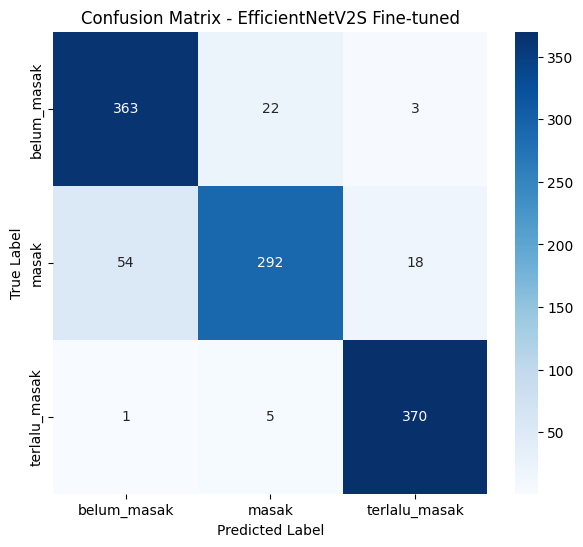

In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = best_model_finetuned.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - EfficientNetV2S Fine-tuned")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
RESULTS_DIR = r"D:\Skripsi\EfficientNetV2S_Sawit\results"
os.makedirs(RESULTS_DIR, exist_ok=True)

report = classification_report(y_true, y_pred, target_names=class_names)

with open(os.path.join(RESULTS_DIR, "classification_report_efficientnetv2s.txt"), "w") as f:
    f.write(report)

print("Classification report berhasil disimpan.")

Classification report berhasil disimpan.


In [27]:
RESULTS_DIR = r"D:\Skripsi\EfficientNetV2S_Sawit\results"
os.makedirs(RESULTS_DIR, exist_ok=True)

summary_text = """
HASIL EVALUASI MODEL EFFICIENTNETV2S FINE-TUNED

Model: EfficientNetV2S
Input Size: 224x224
Batch Size: 16
Optimizer: Adam
Learning Rate Stage 1: 0.0001
Learning Rate Fine-tuning: 0.00001

Stage 1:
Test Accuracy: 0.8245
Test Loss: 0.4595

Fine-tuning:
Test Accuracy: 0.9087
Test Loss: 0.2320

Classification Report:
belum_masak:
- precision: 0.87
- recall: 0.94
- f1-score: 0.90
- support: 388

masak:
- precision: 0.92
- recall: 0.80
- f1-score: 0.86
- support: 364

terlalu_masak:
- precision: 0.95
- recall: 0.98
- f1-score: 0.96
- support: 376

Overall:
- accuracy: 0.91
- macro avg precision: 0.91
- macro avg recall: 0.91
- macro avg f1-score: 0.91
- weighted avg precision: 0.91
- weighted avg recall: 0.91
- weighted avg f1-score: 0.91

Confusion Matrix:
[[363, 22, 3],
 [54, 292, 18],
 [1, 5, 370]]

Catatan:
Model menunjukkan performa terbaik pada kelas terlalu_masak.
Kesalahan terbesar terjadi pada kelas masak yang diprediksi sebagai belum_masak sebanyak 54 citra.
"""

with open(os.path.join(RESULTS_DIR, "summary_efficientnetv2s_finetuned.txt"), "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Ringkasan hasil berhasil disimpan.")

Ringkasan hasil berhasil disimpan.


In [28]:
MODEL_DIR = r"D:\Skripsi\EfficientNetV2S_Sawit\models"

with open(os.path.join(MODEL_DIR, "class_names.txt"), "w", encoding="utf-8") as f:
    for class_name in class_names:
        f.write(class_name + "\n")

print("class_names.txt berhasil disimpan.")

class_names.txt berhasil disimpan.


1/1 [==============================] - 3s 3s/step


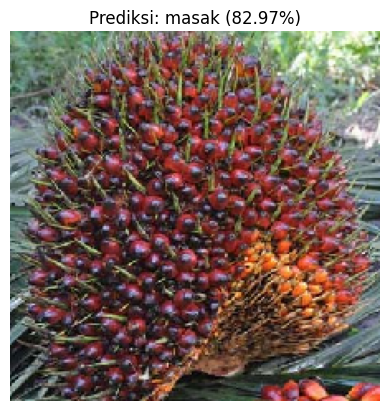

Hasil prediksi: masak
Confidence: 82.97%
Semua probabilitas:
belum_masak: 17.03%
masak: 82.97%
terlalu_masak: 0.00%


In [39]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

MODEL_PATH = r"D:\Skripsi\EfficientNetV2S_Sawit\models\best_efficientnetv2s_sawit_finetuned.keras"
IMAGE_PATH = r"D:\Skripsi\EfficientNetV2S_Sawit\sample_test\tes9.jpg"

model_pred = tf.keras.models.load_model(MODEL_PATH)

img = image.load_img(IMAGE_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array_expanded = np.expand_dims(img_array, axis=0)
img_array_preprocessed = preprocess_input(img_array_expanded)

predictions = model_pred.predict(img_array_preprocessed)
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediksi: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("Hasil prediksi:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")
print("Semua probabilitas:")
for cls, prob in zip(class_names, predictions[0]):
    print(f"{cls}: {prob*100:.2f}%")